# XQuality / NeoOLAF — Prefix Stop-After-Layer Finalization Ablation

This notebook implements the experiment you clarified:

> **What would NeoOLAF's final KG / ontology / JSON look like if it stopped after Layer X?**

For each stop point `X`, it uses the **entire prefix** of results up to that layer. For example, stopping at Layer 3 means using Layers 0, 1, 2, and 3 together, not only the Layer 3 object.

For each prefix, the notebook:

1. loads all saved NeoOLAF states up to the stop layer;
2. builds prefix evidence units from chunks, records, expressions, candidates, assertions, triples, concepts, axioms, etc.;
3. calls OpenRouter/LiteLLM in **parallel batched mode** to finalize the prefix into final triples;
4. deterministically exports `triples.json`, `kg.json`, and `ontology.json`;
5. evaluates the generated triples with the same NeoOLAF evaluator stack used by the original ablation (`evaluate_extraction`, `get_profile`, `load_xquality_gold_any`, `gold_to_artifact`);
6. saves all outputs and plots.

This is different from a naive checkpoint-to-output finalizer: this notebook always uses all evidence accumulated up to the stop layer.

In [1]:
from __future__ import annotations

import os, sys, re, json, time, hashlib
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, is_dataclass
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None


def find_repo_root(start: Path | None = None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    for p in [start] + list(start.parents):
        if (p / "src" / "neoolaf").exists():
            return p
    raise RuntimeError("Could not find NeoOLAF repository root. Open this notebook inside the NeoOLAF repo.")

ROOT = find_repo_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

if load_dotenv:
    load_dotenv(ROOT / ".env")

print("ROOT =", ROOT)
print("Python =", sys.executable)
print("OPENROUTER_API_KEY present =", bool(os.environ.get("OPENROUTER_API_KEY")))

ROOT = C:\Users\henri\Documents\git\post-doc\NeoOLAF
Python = c:\Users\henri\Documents\git\post-doc\neoolafvenv\Scripts\python.exe
OPENROUTER_API_KEY present = True


c:\Users\henri\Documents\git\post-doc\neoolafvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Same profile as the original ablation by default.
PROFILE_NAME = "xquality_loose"

# Main run directory. This should contain layerXX/state.json folders.
RUN_DIR = ROOT / "examples" / "XQualityMachine32" / "runs" / "xquality_machine32"

# Gold path. If Excel is not found, the JSON fallback is tried.
GOLD_PATH = ROOT / "data" / "XQuality" / "Machine32" / "machine32_triples.xlsx"
GOLD_JSON_FALLBACK = ROOT / "data" / "XQuality" / "Examples" / "XQuality_all_triplets_flat_en.json"

# Output directory for this experiment.
OUTPUT_ROOT = ROOT / "examples" / "XQualityMachine32" / "runs" / "prefix_stop_after_layer_llm_finalization_exact_eval"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# OpenRouter / LiteLLM settings.
MODEL = "openrouter/openai/gpt-oss-20b"
TEMPERATURE = 0.0
MAX_TOKENS = 4500
MAX_WORKERS = 4
MAX_RETRIES = 3
RETRY_SLEEP_SECONDS = 2.0

# Batching.
BATCH_SIZE_UNITS = 10
MAX_BATCH_CHARS = 12000
MAX_UNITS_PER_PREFIX = None  # set e.g. 20 for quick test

# Resume / debug.
FORCE_RERUN = False
USE_TQDM = True
VERBOSE = True
PRINT_SALVAGE_WARNINGS = False
SALVAGE_WARNING_THRESHOLD = 3
STRICT_PARSE_ERRORS = False

# Smoke test options.
SMOKE_TEST_ONLY_FIRST_N_PREFIXES = None  # e.g. 2
SMOKE_TEST_MAX_UNITS_PER_PREFIX = None  # e.g. 5

print("OUTPUT_ROOT =", OUTPUT_ROOT)
print("PROFILE_NAME =", PROFILE_NAME)
print("MODEL =", MODEL)

OUTPUT_ROOT = C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval
PROFILE_NAME = xquality_loose
MODEL = openrouter/openai/gpt-oss-20b


In [3]:
from neoolaf.core.pipeline_state import PipelineState
from neoolaf.evaluation.runners.evaluate_layer_state import (
    LAYER_NAMES,
    evaluate_layer_state,
    load_xquality_gold_any,
    gold_to_artifact,
)
from neoolaf.evaluation.metrics.extraction import evaluate_extraction
from neoolaf.evaluation.profiles.registry import get_profile
from neoolaf.evaluation.schema.artifact import EvalDocument, EvalEntity, EvalRelation, EvaluationArtifact

try:
    from litellm import completion
except Exception as e:
    raise RuntimeError("litellm is required. Install/use the same NeoOLAF environment with litellm available.") from e

print("Imported NeoOLAF evaluator and LiteLLM successfully.")

23:06:29 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
23:06:29 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


Imported NeoOLAF evaluator and LiteLLM successfully.


## Discover layer states

In [4]:
def discover_layer_states(run_dir: Path) -> pd.DataFrame:
    rows = []
    for idx, layer_name in enumerate(LAYER_NAMES):
        direct = run_dir / layer_name / "state.json"
        if direct.exists():
            rows.append({"layer_index": idx, "layer_name": layer_name, "state_path": direct})
    if not rows:
        for p in sorted(run_dir.rglob("state.json")):
            parent = p.parent.name
            if parent in LAYER_NAMES:
                rows.append({"layer_index": LAYER_NAMES.index(parent), "layer_name": parent, "state_path": p})
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.drop_duplicates("layer_name").sort_values("layer_index").reset_index(drop=True)
    return df

states_df = discover_layer_states(RUN_DIR)
if states_df.empty:
    print("No states found in RUN_DIR. Trying broader examples/XQualityMachine32/runs folder...")
    states_df = discover_layer_states(ROOT / "examples" / "XQualityMachine32" / "runs")

if SMOKE_TEST_ONLY_FIRST_N_PREFIXES is not None:
    states_df = states_df.head(SMOKE_TEST_ONLY_FIRST_N_PREFIXES).copy()

print("Found states:", len(states_df))
display(states_df)
if states_df.empty:
    raise RuntimeError("No saved layer state.json files found. Check RUN_DIR.")

Found states: 13


,layer_index,layer_name,state_path
0,0,layer00_preprocessing,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
1,1,layer01_linguistic_expression_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
2,2,layer02_candidate_enrichment,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
3,3,layer03_candidate_typing_resolution,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
4,4,layer04_candidate_relation_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
5,5,layer05_candidate_triple_generation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
6,6,layer06_concept_relation_induction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
7,7,layer07_hierarchisation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
8,8,layer08_axiom_schemata_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
9,9,layer09_general_axiom_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...


## Load gold truth and profile with the same NeoOLAF evaluator stack

In [5]:
if not Path(GOLD_PATH).exists() and Path(GOLD_JSON_FALLBACK).exists():
    print("GOLD_PATH not found, using fallback JSON:", GOLD_JSON_FALLBACK)
    GOLD_PATH = GOLD_JSON_FALLBACK

print("GOLD_PATH =", GOLD_PATH, "| exists:", Path(GOLD_PATH).exists())
gold = load_xquality_gold_any(GOLD_PATH)
gold_artifact = gold_to_artifact(gold, profile=PROFILE_NAME)
profile = get_profile(PROFILE_NAME)

print("Gold entities:", sum(len(v) for v in gold_artifact.entities_by_doc.values()))
print("Gold relations:", sum(len(v) for v in gold_artifact.relations_by_doc.values()))
print("Profile:", PROFILE_NAME)

GOLD_PATH = C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\machine32_triples.xlsx | exists: True
Gold entities: 0
Gold relations: 0
Profile: xquality_loose


## Helpers: prefix evidence extraction

In [6]:
def jsonable(value: Any) -> Any:
    if is_dataclass(value):
        return asdict(value)
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, list):
        return [jsonable(x) for x in value]
    if isinstance(value, tuple):
        return [jsonable(x) for x in value]
    if isinstance(value, dict):
        return {str(k): jsonable(v) for k, v in value.items()}
    try:
        json.dumps(value)
        return value
    except Exception:
        return str(value)


def clean_text(x: Any, max_chars: int | None = None) -> str:
    if x is None:
        return ""
    s = re.sub(r"\s+", " ", str(x)).strip()
    if max_chars and len(s) > max_chars:
        return s[:max_chars].rstrip() + " …"
    return s


def get_attr(obj: Any, *names: str, default=None):
    for name in names:
        if isinstance(obj, dict) and name in obj:
            return obj[name]
        if hasattr(obj, name):
            return getattr(obj, name)
    return default


def evidence_to_text(evidence: Any, max_chars: int = 1200) -> str:
    if not evidence:
        return ""
    parts = []
    if isinstance(evidence, list):
        for item in evidence:
            snippet = get_attr(item, "snippet", default=None)
            if snippet:
                parts.append(str(snippet))
            elif isinstance(item, dict) and item.get("text"):
                parts.append(str(item["text"]))
    else:
        snippet = get_attr(evidence, "snippet", default=None)
        if snippet:
            parts.append(str(snippet))
    return clean_text(" | ".join(parts), max_chars=max_chars)


def stable_id(*parts: Any) -> str:
    raw = "||".join(clean_text(p) for p in parts)
    return hashlib.sha1(raw.encode("utf-8", errors="ignore")).hexdigest()[:16]


def add_unit(units: dict[str, dict], *, unit_type: str, layer_name: str, title: str, text: str, metadata: dict | None = None, priority: int = 50):
    text = clean_text(text)
    title = clean_text(title, 200)
    if not text and not title:
        return
    uid = stable_id(unit_type, layer_name, title, text[:500])
    if uid not in units:
        units[uid] = {
            "unit_id": uid,
            "unit_type": unit_type,
            "layer_name": layer_name,
            "title": title,
            "text": text,
            "metadata": metadata or {},
            "priority": priority,
        }


def extract_units_from_state(state: PipelineState, layer_name: str) -> list[dict]:
    units: dict[str, dict] = {}
    doc = getattr(state, "document", None)

    # Structured records from preprocessing: strongest evidence for XQuality tables.
    alarm_records = getattr(doc, "alarm_records", None) if doc is not None else None
    for i, rec in enumerate(alarm_records or []):
        rd = jsonable(rec)
        text = json.dumps(rd, ensure_ascii=False)
        title = clean_text(rd.get("label") or rd.get("text") or rd.get("message") or rd.get("alarm") or f"alarm_record_{i}", 200)
        add_unit(units, unit_type="alarm_record", layer_name=layer_name, title=title, text=text, metadata={"record_index": i}, priority=1)

    # Chunks / cleaned text fallback.
    chunks = getattr(doc, "chunks", None) if doc is not None else None
    for i, ch in enumerate(chunks or []):
        ch_text = get_attr(ch, "text", "content", default="")
        ch_id = get_attr(ch, "chunk_id", "id", default=f"chunk_{i}")
        add_unit(units, unit_type="document_chunk", layer_name=layer_name, title=str(ch_id), text=clean_text(ch_text, 1800), metadata={"chunk_id": ch_id}, priority=20)

    if not chunks and doc is not None:
        cleaned = getattr(doc, "cleaned_text", "") or getattr(doc, "raw_text", "") or ""
        if cleaned:
            pieces = re.split(r"(?=\b(?:Alarme|Alarm|Message)\b)", cleaned)
            for i, piece in enumerate(pieces[:300]):
                piece = clean_text(piece, 1800)
                if len(piece) > 50:
                    add_unit(units, unit_type="text_piece", layer_name=layer_name, title=f"text_piece_{i}", text=piece, priority=25)

    # L1 expressions.
    for i, expr in enumerate(getattr(state, "linguistic_expressions", []) or []):
        label = get_attr(expr, "label", "text", default="")
        ev = evidence_to_text(get_attr(expr, "evidence", default=None))
        text = f"label: {label}\nevidence: {ev}"
        add_unit(units, unit_type="linguistic_expression", layer_name=layer_name, title=label or f"expression_{i}", text=text, metadata={"expr_id": get_attr(expr, "expr_id", default="")}, priority=35)

    # L2 enriched expressions.
    for i, enriched in enumerate(getattr(state, "enriched_expressions", []) or []):
        base = get_attr(enriched, "base_expression", default=None)
        label = get_attr(base, "label", "text", default="") if base else get_attr(enriched, "label", default="")
        aliases = list(get_attr(enriched, "aliases", default=[]) or []) + list(get_attr(enriched, "synonyms", default=[]) or [])
        text = json.dumps({"label": label, "aliases": aliases, "raw": jsonable(enriched)}, ensure_ascii=False)
        add_unit(units, unit_type="enriched_expression", layer_name=layer_name, title=label or f"enriched_{i}", text=clean_text(text, 1800), priority=30)

    # L3+ candidates.
    for field_name, priority in [("entity_candidates", 28), ("event_candidates", 28), ("attribute_candidates", 40), ("relation_candidates", 32)]:
        for i, cand in enumerate(getattr(state, field_name, []) or []):
            label = get_attr(cand, "canonical_label", "label", default="")
            text = json.dumps({"field": field_name, "label": label, "raw": jsonable(cand)}, ensure_ascii=False)
            add_unit(units, unit_type=field_name, layer_name=layer_name, title=label or f"{field_name}_{i}", text=clean_text(text, 1800), priority=priority)

    # L4 assertions.
    for i, assertion in enumerate(getattr(state, "candidate_relation_assertions", []) or []):
        head = get_attr(assertion, "source_candidate_label", default="")
        rel = get_attr(assertion, "relation_label", default="")
        tail = get_attr(assertion, "target_candidate_label", default="")
        text = json.dumps({"source": head, "predicate": rel, "target": tail, "raw": jsonable(assertion)}, ensure_ascii=False)
        add_unit(units, unit_type="candidate_relation_assertion", layer_name=layer_name, title=f"{head} {rel} {tail}", text=text, priority=5)

    # L5+ triples.
    for i, triple in enumerate(getattr(state, "candidate_triples", []) or []):
        subj = get_attr(triple, "subject_label", default="")
        pred = get_attr(triple, "predicate_label", "predicate", default="")
        obj = get_attr(triple, "object_label", default="")
        text = json.dumps({"subject_label": subj, "predicate": pred, "object_label": obj, "raw": jsonable(triple)}, ensure_ascii=False)
        add_unit(units, unit_type="candidate_triple", layer_name=layer_name, title=f"{subj} {pred} {obj}", text=text, priority=2)

    # L6+ semantic context.
    semantic_fields = [
        "concept_candidates", "ontology_relation_candidates", "concept_hierarchy_links", "relation_hierarchy_links",
        "axiom_schema_candidates", "general_axiom_candidates", "completion_candidates", "reasoning_inferred_triples",
    ]
    for field_name in semantic_fields:
        for i, item in enumerate(getattr(state, field_name, []) or []):
            label = get_attr(item, "label", "canonical_label", default=f"{field_name}_{i}")
            text = json.dumps({"field": field_name, "label": label, "raw": jsonable(item)}, ensure_ascii=False)
            add_unit(units, unit_type=field_name, layer_name=layer_name, title=label, text=clean_text(text, 1600), priority=45)
    return list(units.values())


def load_prefix_states(states_df: pd.DataFrame, stop_index: int) -> list[tuple[str, PipelineState]]:
    rows = states_df[states_df["layer_index"] <= stop_index].sort_values("layer_index")
    out = []
    for _, row in rows.iterrows():
        state = PipelineState.load_json(str(row["state_path"]))
        out.append((row["layer_name"], state))
    return out


def build_prefix_units(states_df: pd.DataFrame, stop_index: int) -> list[dict]:
    merged: dict[str, dict] = {}
    for layer_name, state in load_prefix_states(states_df, stop_index):
        for unit in extract_units_from_state(state, layer_name):
            key = stable_id(unit["unit_type"], unit["title"], unit["text"][:500])
            if key not in merged or unit.get("priority", 999) < merged[key].get("priority", 999):
                merged[key] = unit
    units = list(merged.values())
    units.sort(key=lambda u: (u.get("priority", 999), u.get("unit_type", ""), u.get("title", "")))
    if MAX_UNITS_PER_PREFIX is not None:
        units = units[:MAX_UNITS_PER_PREFIX]
    if SMOKE_TEST_MAX_UNITS_PER_PREFIX is not None:
        units = units[:SMOKE_TEST_MAX_UNITS_PER_PREFIX]
    return units

## Prompt, parsing, batching, and OpenRouter calls

In [7]:
ALLOWED_PREDICATES = {"TRIGGERS", "CAUSES", "REQUIRES", "HANDLED_BY", "REFERENCES"}

SYSTEM_PROMPT = """You are a strict information extraction finalizer for the XQuality Machine32 alarm/message document.
You receive NeoOLAF prefix evidence from all layers available up to a stop point.
Your task is to generate final relation triples for the final KG/ontology JSON.

Use exactly these predicates and directions:
- TRIGGERS: cause/explanation -> alarm/message
- CAUSES: alarm/message -> effect/consequence
- REQUIRES: alarm/message -> intervention/action
- HANDLED_BY: alarm/message -> responsible actor
- REFERENCES: alarm/message -> technical reference/page/input/schema

Important aliases:
- opérateur = Operator
- chargé de l'entretien = Maintenance Technician
- programmeur = Programmer
- outilleur-régleur = Tool setter

Output format:
Return JSONL only. Each line must be one JSON object with these keys:
{"subject_label": str, "predicate": str, "object_label": str, "confidence": float, "evidence_unit_ids": [str]}

Do not use Markdown. Do not wrap in code fences. Do not add explanations.
If there are no triples, return nothing."""


def build_user_prompt(prefix_layer_name: str, batch_units: list[dict]) -> str:
    compact_units = []
    for u in batch_units:
        compact_units.append({
            "unit_id": u["unit_id"],
            "unit_type": u["unit_type"],
            "source_layer": u["layer_name"],
            "title": clean_text(u.get("title", ""), 180),
            "text": clean_text(u.get("text", ""), 1500),
        })
    return (
        f"Stop point: {prefix_layer_name}\n"
        "Use all evidence units below as the available NeoOLAF prefix state.\n"
        "Generate only triples directly supported by these units, respecting XQuality predicate directions.\n\n"
        f"EVIDENCE_UNITS_JSON:\n{json.dumps(compact_units, ensure_ascii=False)}"
    )


def canonical_predicate(p: Any) -> str:
    s = clean_text(p).upper()
    s = re.sub(r"[^A-Z0-9]+", "_", s).strip("_")
    aliases = {
        "TRIGGER": "TRIGGERS", "TRIGGERS": "TRIGGERS",
        "CAUSE": "CAUSES", "CAUSES": "CAUSES", "EFFECT": "CAUSES", "EFFET": "CAUSES",
        "REQUIRES": "REQUIRES", "REQUIRE": "REQUIRES", "INTERVENTION": "REQUIRES", "ACTION": "REQUIRES",
        "HANDLED_BY": "HANDLED_BY", "RESPONSIBLE": "HANDLED_BY", "RESPONSABLE": "HANDLED_BY",
        "REFERENCES": "REFERENCES", "REFERENCE": "REFERENCES", "REF": "REFERENCES",
    }
    return aliases.get(s, s)


def normalize_triple(t: dict, fallback_unit_ids: list[str] | None = None) -> dict | None:
    subj = clean_text(t.get("subject_label") or t.get("subject") or t.get("head"))
    pred = canonical_predicate(t.get("predicate") or t.get("relation") or t.get("property"))
    obj = clean_text(t.get("object_label") or t.get("object") or t.get("tail"))
    if not subj or not pred or not obj or pred not in ALLOWED_PREDICATES:
        return None
    try:
        conf = float(t.get("confidence", 0.7))
    except Exception:
        conf = 0.7
    conf = min(max(conf, 0.0), 1.0)
    eids = t.get("evidence_unit_ids") or fallback_unit_ids or []
    if isinstance(eids, str):
        eids = [eids]
    return {"subject_label": subj, "predicate": pred, "object_label": obj, "confidence": conf, "evidence_unit_ids": [str(x) for x in eids]}


def strip_fences(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"^```(?:jsonl|json)?\s*", "", text, flags=re.I)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()


def parse_json_objects_from_text(text: str) -> tuple[list[dict], dict]:
    raw = strip_fences(text)
    diag = {"parser": None, "bad_lines": 0, "salvaged": False, "raw_chars": len(raw)}
    if not raw:
        diag["parser"] = "empty"
        return [], diag
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict) and "triples" in obj:
            arr = obj.get("triples") or []
        elif isinstance(obj, list):
            arr = obj
        elif isinstance(obj, dict):
            arr = [obj]
        else:
            arr = []
        diag["parser"] = "full_json"
        return [x for x in arr if isinstance(x, dict)], diag
    except Exception:
        pass

    records, bad = [], 0
    for line in raw.splitlines():
        line = line.strip().rstrip(",")
        if not line:
            continue
        if line.startswith("```") or line.lower().startswith("here") or line in {"[", "]"}:
            bad += 1
            continue
        try:
            obj = json.loads(line)
            if isinstance(obj, dict):
                records.append(obj)
            else:
                bad += 1
        except Exception:
            bad += 1
    if records:
        diag.update({"parser": "jsonl", "bad_lines": bad, "salvaged": bad > 0})
        return records, diag

    # Balanced-object salvage.
    records = []
    depth, start, in_str, esc = 0, None, False, False
    for i, ch in enumerate(raw):
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "{":
                if depth == 0:
                    start = i
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0 and start is not None:
                    piece = raw[start:i+1]
                    try:
                        obj = json.loads(piece)
                        if isinstance(obj, dict):
                            records.append(obj)
                    except Exception:
                        pass
                    start = None
    if records:
        diag.update({"parser": "balanced_object_salvage", "salvaged": True})
        return records, diag
    diag.update({"parser": "failed", "bad_lines": len(raw.splitlines())})
    return [], diag


def parse_triples_response(text: str, fallback_unit_ids: list[str]) -> tuple[list[dict], dict]:
    objects, diag = parse_json_objects_from_text(text)
    triples = []
    for obj in objects:
        t = normalize_triple(obj, fallback_unit_ids=fallback_unit_ids)
        if t:
            triples.append(t)
    diag["valid_triples"] = len(triples)
    return triples, diag


def unit_char_len(u: dict) -> int:
    return len(json.dumps(u, ensure_ascii=False))


def make_batches(units: list[dict], batch_size: int = BATCH_SIZE_UNITS, max_chars: int = MAX_BATCH_CHARS) -> list[list[dict]]:
    batches, cur, cur_chars = [], [], 0
    for u in units:
        n = unit_char_len(u)
        if cur and (len(cur) >= batch_size or cur_chars + n > max_chars):
            batches.append(cur)
            cur, cur_chars = [], 0
        cur.append(u)
        cur_chars += n
    if cur:
        batches.append(cur)
    return batches


def litellm_call(messages: list[dict], *, max_tokens: int = MAX_TOKENS, temperature: float = TEMPERATURE) -> str:
    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = completion(model=MODEL, messages=messages, temperature=temperature, max_tokens=max_tokens)
            return resp.choices[0].message.content or ""
        except Exception as e:
            last_err = e
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_SLEEP_SECONDS * attempt)
    raise RuntimeError(f"LLM call failed after {MAX_RETRIES} attempts: {last_err}")


def process_batch(prefix_layer_name: str, batch_id: int, batch_units: list[dict]) -> dict:
    unit_ids = [u["unit_id"] for u in batch_units]
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(prefix_layer_name, batch_units)},
    ]
    t0 = time.time()
    raw = litellm_call(messages)
    elapsed = time.time() - t0
    triples, diag = parse_triples_response(raw, fallback_unit_ids=unit_ids)
    status = "salvaged" if diag.get("salvaged") else "ok"
    if diag.get("parser") == "failed" and STRICT_PARSE_ERRORS:
        raise ValueError(f"Could not parse response for batch {batch_id}: {raw[:500]}")
    return {"batch_id": batch_id, "status": status, "triples": triples, "diagnostics": diag, "raw_response": raw, "elapsed_seconds": elapsed, "unit_count": len(batch_units), "unit_ids": unit_ids}


def run_prefix_finalizer(prefix_layer_name: str, units: list[dict], out_dir: Path) -> tuple[list[dict], pd.DataFrame]:
    batches = make_batches(units)
    print(f"[{prefix_layer_name}] units={len(units)} batches={len(batches)} batch_size={BATCH_SIZE_UNITS} max_workers={MAX_WORKERS}")
    batch_rows, all_triples = [], []
    raw_dir = out_dir / "raw_batches"
    raw_dir.mkdir(parents=True, exist_ok=True)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_batch, prefix_layer_name, i, b): (i, b) for i, b in enumerate(batches)}
        iterator = as_completed(futures)
        if USE_TQDM:
            iterator = tqdm(iterator, total=len(futures), desc=f"{prefix_layer_name} LLM batches")
        completed = 0
        for fut in iterator:
            batch_id, batch_units = futures[fut]
            try:
                result = fut.result()
            except Exception as e:
                result = {"batch_id": batch_id, "status": "error", "triples": [], "diagnostics": {"error": repr(e), "parser": "exception", "valid_triples": 0}, "raw_response": "", "elapsed_seconds": None, "unit_count": len(batch_units), "unit_ids": [u["unit_id"] for u in batch_units]}
                print(f"[ERROR] {prefix_layer_name} batch {batch_id}: {e}")
            completed += 1
            all_triples.extend(result["triples"])
            diag = result.get("diagnostics") or {}
            if result["status"] == "salvaged" and PRINT_SALVAGE_WARNINGS and diag.get("bad_lines", 0) >= SALVAGE_WARNING_THRESHOLD:
                print(f"[SALVAGED] {prefix_layer_name} batch {batch_id}: {diag}")
            (raw_dir / f"batch_{batch_id:04d}.json").write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
            batch_rows.append({"prefix_layer": prefix_layer_name, "batch_id": batch_id, "status": result["status"], "unit_count": result["unit_count"], "valid_triples": len(result["triples"]), "parser": diag.get("parser"), "bad_lines": diag.get("bad_lines", 0), "salvaged": diag.get("salvaged", False), "elapsed_seconds": result.get("elapsed_seconds")})
            if VERBOSE and (completed % 5 == 0 or completed == len(batches)):
                ok = sum(1 for r in batch_rows if r["status"] in {"ok", "salvaged"})
                err = sum(1 for r in batch_rows if r["status"] == "error")
                print(f"[{prefix_layer_name}] completed {completed}/{len(batches)} batches | ok/salvaged={ok} errors={err} triples_so_far={len(all_triples)}")
    return all_triples, pd.DataFrame(batch_rows).sort_values("batch_id")

## Deterministic export and exact evaluation

In [8]:
def dedup_triples(triples: list[dict]) -> list[dict]:
    seen = {}
    for t in triples:
        nt = normalize_triple(t)
        if not nt:
            continue
        key = (nt["subject_label"].lower(), nt["predicate"], nt["object_label"].lower())
        if key not in seen or nt.get("confidence", 0) > seen[key].get("confidence", 0):
            seen[key] = nt
    out = []
    for i, t in enumerate(seen.values()):
        t = dict(t)
        t["triple_id"] = f"prefix_triple_{i:05d}"
        out.append(t)
    return out


def build_kg(triples: list[dict]) -> dict:
    nodes, edges = {}, []
    for t in triples:
        s, p, o = t["subject_label"], t["predicate"], t["object_label"]
        sid, oid = "node_" + stable_id(s), "node_" + stable_id(o)
        nodes[sid] = {"id": sid, "label": s}
        nodes[oid] = {"id": oid, "label": o}
        edges.append({"id": "edge_" + stable_id(s, p, o), "source": sid, "target": oid, "predicate": p, "confidence": t.get("confidence"), "triple_id": t.get("triple_id")})
    return {"nodes": list(nodes.values()), "edges": edges}


def build_ontology(triples: list[dict]) -> dict:
    concepts, properties = {}, {}
    directions = {
        "TRIGGERS": "cause/explanation -> alarm/message",
        "CAUSES": "alarm/message -> effect/consequence",
        "REQUIRES": "alarm/message -> intervention/action",
        "HANDLED_BY": "alarm/message -> responsible actor",
        "REFERENCES": "alarm/message -> technical reference",
    }
    for t in triples:
        for label in [t["subject_label"], t["object_label"]]:
            cid = "concept_" + stable_id(label)
            concepts[cid] = {"id": cid, "label": label}
        pred = t["predicate"]
        properties[pred] = {"id": pred, "label": pred, "type": "object_property", "expected_direction": directions.get(pred, "")}
    return {"concepts": list(concepts.values()), "object_properties": list(properties.values())}


def artifact_from_generated_triples(triples: list[dict], *, run_id: str, profile_name: str = PROFILE_NAME) -> EvaluationArtifact:
    doc_id = "xquality"
    artifact = EvaluationArtifact(method="prefix_stop_after_layer_llm_finalization", dataset="xquality", profile=profile_name, run_id=run_id, metadata={"evaluation_input": "generated_triples", "profile": profile_name})
    artifact.documents.append(EvalDocument(document_id=doc_id, metadata={"dataset": "xquality"}))
    entities, relations = {}, []
    for t in triples:
        subj, pred, obj = t["subject_label"], t["predicate"], t["object_label"]
        for label in [subj, obj]:
            key = label.lower()
            if key not in entities:
                entities[key] = EvalEntity(label=label, id="ent_" + stable_id(label), type=None, evidence="", provenance_present=bool(t.get("evidence_unit_ids")), raw={"source": "prefix_finalizer"})
        relations.append(EvalRelation(head=subj, relation=pred, tail=obj, evidence=";".join(t.get("evidence_unit_ids") or []), confidence=t.get("confidence"), provenance_present=bool(t.get("evidence_unit_ids")), provenance={"evidence_unit_ids": t.get("evidence_unit_ids") or []}, raw=t))
    artifact.entities_by_doc[doc_id] = sorted(entities.values(), key=lambda e: e.label.lower())
    artifact.relations_by_doc[doc_id] = relations
    return artifact


def extract_metric_rows(extraction: dict, *, layer_name: str, series: str, output_dir: str, profile_name: str = PROFILE_NAME) -> tuple[dict, list[dict]]:
    counts = extraction.get("counts", {}) or {}
    entity = extraction.get("entity", {}) or extraction.get("entities", {}) or {}
    relation = extraction.get("relation", {}) or extraction.get("relations", {}) or {}
    def gm(block, name, default=0.0): return block.get(name, default) if isinstance(block, dict) else default
    summary = {"series": series, "layer_name": layer_name, "evaluation_mode": "exact_neoolaf_evaluate_extraction", "profile": profile_name, "output_dir": output_dir, "entity_precision": gm(entity, "precision"), "entity_recall": gm(entity, "recall"), "entity_f1": gm(entity, "f1"), "relation_precision": gm(relation, "precision"), "relation_recall": gm(relation, "recall"), "relation_f1": gm(relation, "f1")}
    for k, v in counts.items():
        if isinstance(v, (int, float, str, bool)) or v is None:
            summary[f"count_{k}"] = v
    per_rows = []
    per_relation = extraction.get("per_relation", {}) or extraction.get("relations_by_type", {}) or {}
    if isinstance(per_relation, dict):
        for rel, vals in per_relation.items():
            if isinstance(vals, dict):
                row = {"series": series, "layer_name": layer_name, "profile": profile_name, "relation": rel}
                row.update({k: v for k, v in vals.items() if isinstance(v, (int, float, str, bool)) or v is None})
                per_rows.append(row)
    return summary, per_rows


def evaluate_generated_triples(triples: list[dict], *, run_id: str, layer_name: str, out_dir: Path) -> tuple[dict, list[dict], dict]:
    pred_artifact = artifact_from_generated_triples(triples, run_id=run_id, profile_name=PROFILE_NAME)
    extraction = evaluate_extraction(pred_artifact, gold_artifact, profile)
    summary, per_rel = extract_metric_rows(extraction, layer_name=layer_name, series="prefix_stop_after_layer_finalized_with_llm", output_dir=str(out_dir), profile_name=PROFILE_NAME)
    return summary, per_rel, extraction

## Call plan preview

In [9]:
plan_rows = []
for _, row in states_df.iterrows():
    idx, lname = int(row["layer_index"]), row["layer_name"]
    units = build_prefix_units(states_df, idx)
    batches = make_batches(units)
    by_type = Counter(u["unit_type"] for u in units)
    plan_rows.append({"stop_layer_index": idx, "stop_layer_name": lname, "prefix_state_count": len(states_df[states_df["layer_index"] <= idx]), "units": len(units), "estimated_llm_calls": len(batches), "top_unit_types": dict(by_type.most_common(8))})
plan_df = pd.DataFrame(plan_rows)
plan_path = OUTPUT_ROOT / "call_plan.csv"
plan_df.to_csv(plan_path, index=False)
print("Saved call plan:", plan_path)
display(plan_df)

Saved call plan: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\call_plan.csv


,stop_layer_index,stop_layer_name,prefix_state_count,units,estimated_llm_calls,top_unit_types
0,0,layer00_preprocessing,1,83,9,{'document_chunk': 83}
1,1,layer01_linguistic_expression_extraction,2,458,79,"{'linguistic_expression': 292, 'alarm_record':..."
2,2,layer02_candidate_enrichment,3,768,140,"{'enriched_expression': 310, 'linguistic_expre..."
3,3,layer03_candidate_typing_resolution,4,1058,184,"{'enriched_expression': 310, 'linguistic_expre..."
4,4,layer04_candidate_relation_extraction,5,1903,330,"{'enriched_expression': 620, 'linguistic_expre..."
5,5,layer05_candidate_triple_generation,6,2129,387,"{'enriched_expression': 620, 'linguistic_expre..."
6,6,layer06_concept_relation_induction,7,2438,427,"{'enriched_expression': 620, 'concept_candidat..."
7,7,layer07_hierarchisation,8,2747,461,"{'enriched_expression': 620, 'concept_candidat..."
8,8,layer08_axiom_schemata_extraction,9,3066,500,"{'enriched_expression': 620, 'axiom_schema_can..."
9,9,layer09_general_axiom_extraction,10,3694,583,"{'general_axiom_candidates': 628, 'enriched_ex..."


## Main run: prefix stop-after-layer finalization

In [10]:
summary_rows, per_relation_rows, raw_results, status_rows = [], [], [], []
progress_log = OUTPUT_ROOT / "progress.log"
progress_log.write_text("", encoding="utf-8")

def log(msg: str):
    print(msg)
    with open(progress_log, "a", encoding="utf-8") as f:
        f.write(msg + "\n")

state_iter = list(states_df.iterrows())
if USE_TQDM:
    state_iter = tqdm(state_iter, total=len(states_df), desc="Stop-after-layer prefixes")

for _, row in state_iter:
    stop_idx, stop_layer = int(row["layer_index"]), row["layer_name"]
    prefix_name = f"prefix_stop_after_{stop_idx:02d}_{stop_layer}"
    out_dir = OUTPUT_ROOT / prefix_name
    out_dir.mkdir(parents=True, exist_ok=True)
    triples_path, metrics_path, batch_meta_path = out_dir / "triples.json", out_dir / "metrics.json", out_dir / "batch_metadata.csv"
    log(f"\n=== {prefix_name} ===")
    t0 = time.time()

    if (not FORCE_RERUN) and triples_path.exists() and metrics_path.exists():
        log(f"[RESUME] Loading existing outputs from {out_dir}")
        triples = json.loads(triples_path.read_text(encoding="utf-8"))
        extraction = json.loads(metrics_path.read_text(encoding="utf-8")).get("extraction", {})
        summary, per_rel = extract_metric_rows(extraction, layer_name=stop_layer, series="prefix_stop_after_layer_finalized_with_llm", output_dir=str(out_dir), profile_name=PROFILE_NAME)
        batch_df = pd.read_csv(batch_meta_path) if batch_meta_path.exists() else pd.DataFrame()
    else:
        units = build_prefix_units(states_df, stop_idx)
        (out_dir / "prefix_units.json").write_text(json.dumps(units, indent=2, ensure_ascii=False), encoding="utf-8")
        triples_raw, batch_df = run_prefix_finalizer(stop_layer, units, out_dir)
        triples = dedup_triples(triples_raw)
        kg, ontology = build_kg(triples), build_ontology(triples)
        triples_path.write_text(json.dumps(triples, indent=2, ensure_ascii=False), encoding="utf-8")
        (out_dir / "kg.json").write_text(json.dumps(kg, indent=2, ensure_ascii=False), encoding="utf-8")
        (out_dir / "ontology.json").write_text(json.dumps(ontology, indent=2, ensure_ascii=False), encoding="utf-8")
        batch_df.to_csv(batch_meta_path, index=False)
        summary, per_rel, extraction = evaluate_generated_triples(triples, run_id=prefix_name, layer_name=stop_layer, out_dir=out_dir)
        metrics_path.write_text(json.dumps({"summary": summary, "extraction": extraction}, indent=2, ensure_ascii=False), encoding="utf-8")

    elapsed = time.time() - t0
    summary["elapsed_seconds_total"] = elapsed
    summary["generated_triples"] = len(triples)
    summary["batches"] = len(batch_df) if isinstance(batch_df, pd.DataFrame) else None
    summary["batch_errors"] = int((batch_df["status"] == "error").sum()) if isinstance(batch_df, pd.DataFrame) and "status" in batch_df else 0
    summary["batch_salvaged"] = int((batch_df["status"] == "salvaged").sum()) if isinstance(batch_df, pd.DataFrame) and "status" in batch_df else 0
    summary_rows.append(summary)
    per_relation_rows.extend(per_rel)
    raw_results.append({"prefix_name": prefix_name, "summary": summary, "output_dir": str(out_dir)})
    status_rows.append(summary)
    pd.DataFrame(status_rows).to_csv(OUTPUT_ROOT / "run_status.csv", index=False)
    log(f"[{prefix_name}] triples={len(triples)} relation_f1={summary.get('relation_f1')} precision={summary.get('relation_precision')} recall={summary.get('relation_recall')} elapsed={elapsed:.1f}s")

summary_df = pd.DataFrame(summary_rows)
per_relation_df = pd.DataFrame(per_relation_rows)
summary_df.to_csv(OUTPUT_ROOT / "summary_exact_eval.csv", index=False)
per_relation_df.to_csv(OUTPUT_ROOT / "per_relation_exact_eval.csv", index=False)
(OUTPUT_ROOT / "raw_results.json").write_text(json.dumps(raw_results, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved summary:", OUTPUT_ROOT / "summary_exact_eval.csv")
display(summary_df)

Stop-after-layer prefixes:   0%|          | 0/13 [00:00<?, ?it/s]

Stop-after-layer prefixes:  23%|██▎       | 3/13 [00:00<00:00, 22.85it/s]


=== prefix_stop_after_00_layer00_preprocessing ===
[RESUME] Loading existing outputs from C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_00_layer00_preprocessing
[prefix_stop_after_00_layer00_preprocessing] triples=124 relation_f1=0.0 precision=0.0 recall=0.0 elapsed=0.0s

=== prefix_stop_after_01_layer01_linguistic_expression_extraction ===
[RESUME] Loading existing outputs from C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_01_layer01_linguistic_expression_extraction
[prefix_stop_after_01_layer01_linguistic_expression_extraction] triples=841 relation_f1=0.0 precision=0.0 recall=0.0 elapsed=0.0s

=== prefix_stop_after_02_layer02_candidate_enrichment ===
[RESUME] Loading existing outputs from C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after

Stop-after-layer prefixes:  46%|████▌     | 6/13 [00:00<00:00, 20.06it/s]

[prefix_stop_after_04_layer04_candidate_relation_extraction] triples=2669 relation_f1=0.0 precision=0.0 recall=0.0 elapsed=0.0s

=== prefix_stop_after_05_layer05_candidate_triple_generation ===
[RESUME] Loading existing outputs from C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_05_layer05_candidate_triple_generation
[prefix_stop_after_05_layer05_candidate_triple_generation] triples=2657 relation_f1=0.0 precision=0.0 recall=0.0 elapsed=0.0s

=== prefix_stop_after_06_layer06_concept_relation_induction ===
[layer06_concept_relation_induction] units=2438 batches=427 batch_size=10 max_workers=4


...

layer12_serialization LLM batches: 100%|██████████| 1082/1082 [2:12:30<00:00,  7.35s/it] 

[layer12_serialization] completed 1082/1082 batches | ok/salvaged=1082 errors=0 triples_so_far=7494



Stop-after-layer prefixes: 100%|██████████| 13/13 [10:22:41<00:00, 2873.97s/it] 

[prefix_stop_after_12_layer12_serialization] triples=3981 relation_f1=0.0 precision=0.0 recall=0.0 elapsed=7957.5s
Saved summary: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\summary_exact_eval.csv


,series,layer_name,evaluation_mode,profile,output_dir,entity_precision,entity_recall,entity_f1,relation_precision,relation_recall,relation_f1,count_pred_entities,count_gold_entities,count_pred_relations,count_gold_relations,elapsed_seconds_total,generated_triples,batches,batch_errors,batch_salvaged
0,prefix_stop_after_layer_finalized_with_llm,layer00_preprocessing,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,96,0,124,0,0.012434,124,9,0,5
1,prefix_stop_after_layer_finalized_with_llm,layer01_linguistic_expression_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,652,0,841,0,0.014795,841,79,0,65
2,prefix_stop_after_layer_finalized_with_llm,layer02_candidate_enrichment,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,930,0,1428,0,0.017993,1428,140,0,122
3,prefix_stop_after_layer_finalized_with_llm,layer03_candidate_typing_resolution,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1096,0,1812,0,0.026579,1812,184,0,157
4,prefix_stop_after_layer_finalized_with_llm,layer04_candidate_relation_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1407,0,2669,0,0.033577,2669,330,0,285
5,prefix_stop_after_layer_finalized_with_llm,layer05_candidate_triple_generation,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1271,0,2657,0,0.031584,2657,387,0,334
6,prefix_stop_after_layer_finalized_with_llm,layer06_concept_relation_induction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1372,0,2742,0,3006.413954,2742,427,0,372
7,prefix_stop_after_layer_finalized_with_llm,layer07_hierarchisation,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1262,0,2642,0,4444.312739,2642,461,0,367
8,prefix_stop_after_layer_finalized_with_llm,layer08_axiom_schemata_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1318,0,2881,0,4135.635603,2881,500,0,402
9,prefix_stop_after_layer_finalized_with_llm,layer09_general_axiom_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1409,0,3121,0,4830.174013,3121,583,0,435


## Optional diagnostic: native saved-state reference

In [11]:
native_rows, native_per_rel = [], []
native_eval_dir = OUTPUT_ROOT / "native_layer_state_reference"
native_eval_dir.mkdir(parents=True, exist_ok=True)

for _, row in tqdm(list(states_df.iterrows()), desc="Native state reference"):
    result = evaluate_layer_state(state_path=row["state_path"], gold_path=GOLD_PATH, profile_name=PROFILE_NAME, layer_name=row["layer_name"], output_path=native_eval_dir / f"{row['layer_name']}_eval.json")
    extraction = result.get("extraction", {})
    summary, per_rel = extract_metric_rows(extraction, layer_name=row["layer_name"], series="native_saved_state_reference", output_dir=str(native_eval_dir), profile_name=PROFILE_NAME)
    native_rows.append(summary)
    native_per_rel.extend(per_rel)

native_df = pd.DataFrame(native_rows)
native_rel_df = pd.DataFrame(native_per_rel)
native_df.to_csv(OUTPUT_ROOT / "native_layer_state_reference_summary.csv", index=False)
native_rel_df.to_csv(OUTPUT_ROOT / "native_layer_state_reference_per_relation.csv", index=False)
display(native_df)

Native state reference: 100%|██████████| 13/13 [00:05<00:00,  2.57it/s]


,series,layer_name,evaluation_mode,profile,output_dir,entity_precision,entity_recall,entity_f1,relation_precision,relation_recall,relation_f1,count_pred_entities,count_gold_entities,count_pred_relations,count_gold_relations
0,native_saved_state_reference,layer00_preprocessing,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
1,native_saved_state_reference,layer01_linguistic_expression_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,7,0,0,0
2,native_saved_state_reference,layer02_candidate_enrichment,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1033,0,0,0
3,native_saved_state_reference,layer03_candidate_typing_resolution,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,1295,0,0,0
4,native_saved_state_reference,layer04_candidate_relation_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,350,0,226,0
5,native_saved_state_reference,layer05_candidate_triple_generation,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,350,0,452,0
6,native_saved_state_reference,layer06_concept_relation_induction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,350,0,452,0
7,native_saved_state_reference,layer07_hierarchisation,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,350,0,452,0
8,native_saved_state_reference,layer08_axiom_schemata_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,350,0,452,0
9,native_saved_state_reference,layer09_general_axiom_extraction,exact_neoolaf_evaluate_extraction,xquality_loose,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,0.0,0.0,0.0,0.0,0.0,0.0,350,0,452,0


## Consolidated tables and plots

Saved combined summary: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\combined_summary.csv


,series,layer_name,profile,generated_triples,relation_precision,relation_recall,relation_f1,entity_f1,batch_errors,batch_salvaged
0,prefix_stop_after_layer_finalized_with_llm,layer00_preprocessing,xquality_loose,124.0,0.0,0.0,0.0,0.0,0.0,5.0
1,prefix_stop_after_layer_finalized_with_llm,layer01_linguistic_expression_extraction,xquality_loose,841.0,0.0,0.0,0.0,0.0,0.0,65.0
2,prefix_stop_after_layer_finalized_with_llm,layer02_candidate_enrichment,xquality_loose,1428.0,0.0,0.0,0.0,0.0,0.0,122.0
3,prefix_stop_after_layer_finalized_with_llm,layer03_candidate_typing_resolution,xquality_loose,1812.0,0.0,0.0,0.0,0.0,0.0,157.0
4,prefix_stop_after_layer_finalized_with_llm,layer04_candidate_relation_extraction,xquality_loose,2669.0,0.0,0.0,0.0,0.0,0.0,285.0
5,prefix_stop_after_layer_finalized_with_llm,layer05_candidate_triple_generation,xquality_loose,2657.0,0.0,0.0,0.0,0.0,0.0,334.0
6,prefix_stop_after_layer_finalized_with_llm,layer06_concept_relation_induction,xquality_loose,2742.0,0.0,0.0,0.0,0.0,0.0,372.0
7,prefix_stop_after_layer_finalized_with_llm,layer07_hierarchisation,xquality_loose,2642.0,0.0,0.0,0.0,0.0,0.0,367.0
8,prefix_stop_after_layer_finalized_with_llm,layer08_axiom_schemata_extraction,xquality_loose,2881.0,0.0,0.0,0.0,0.0,0.0,402.0
9,prefix_stop_after_layer_finalized_with_llm,layer09_general_axiom_extraction,xquality_loose,3121.0,0.0,0.0,0.0,0.0,0.0,435.0


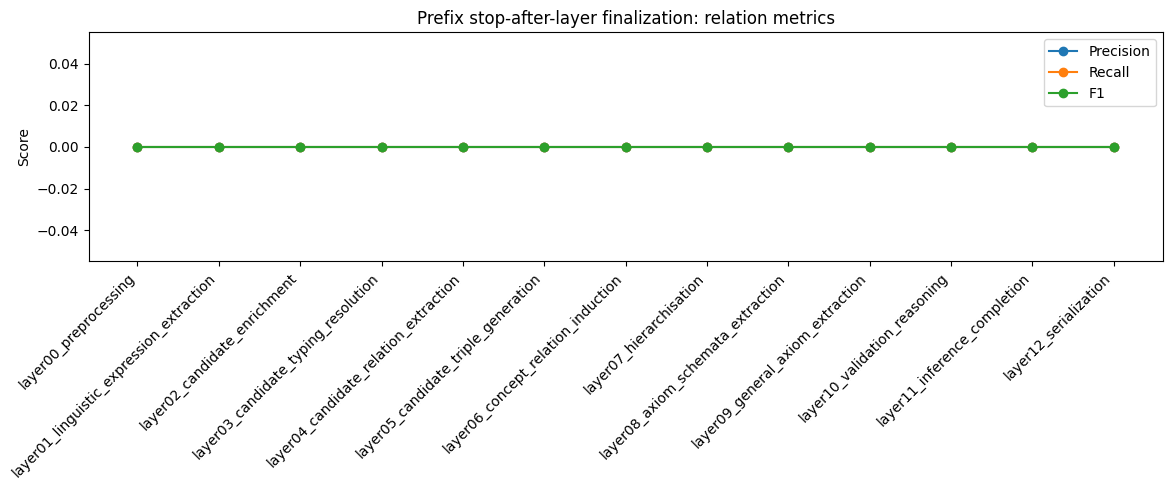

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\relation_metrics_prefix_stop_after_layer.png


In [12]:
summary_df = pd.read_csv(OUTPUT_ROOT / "summary_exact_eval.csv") if (OUTPUT_ROOT / "summary_exact_eval.csv").exists() else pd.DataFrame()
native_df = pd.read_csv(OUTPUT_ROOT / "native_layer_state_reference_summary.csv") if (OUTPUT_ROOT / "native_layer_state_reference_summary.csv").exists() else pd.DataFrame()
combined_df = pd.concat([summary_df, native_df], ignore_index=True, sort=False)
if "profile" in combined_df.columns:
    combined_df["profile"] = combined_df["profile"].fillna(PROFILE_NAME)
combined_path = OUTPUT_ROOT / "combined_summary.csv"
combined_df.to_csv(combined_path, index=False)
print("Saved combined summary:", combined_path)
cols = [c for c in ["series", "layer_name", "profile", "generated_triples", "relation_precision", "relation_recall", "relation_f1", "entity_f1", "batch_errors", "batch_salvaged"] if c in combined_df.columns]
display(combined_df[cols])

plot_df = summary_df.copy()
if not plot_df.empty:
    plot_df["layer_order"] = plot_df["layer_name"].map({name: i for i, name in enumerate(LAYER_NAMES)})
    plot_df = plot_df.sort_values("layer_order")
    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["layer_name"], plot_df["relation_precision"], marker="o", label="Precision")
    plt.plot(plot_df["layer_name"], plot_df["relation_recall"], marker="o", label="Recall")
    plt.plot(plot_df["layer_name"], plot_df["relation_f1"], marker="o", label="F1")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title("Prefix stop-after-layer finalization: relation metrics")
    plt.legend()
    plt.tight_layout()
    fig_path = OUTPUT_ROOT / "relation_metrics_prefix_stop_after_layer.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

## Inspect generated triples for one stop layer

In [ ]:
INSPECT_LAYER_NAME = states_df.iloc[-1]["layer_name"]
inspect_dirs = [p for p in OUTPUT_ROOT.iterdir() if p.is_dir() and p.name.endswith(INSPECT_LAYER_NAME)]
if inspect_dirs:
    inspect_dir = inspect_dirs[0]
    triples = json.loads((inspect_dir / "triples.json").read_text(encoding="utf-8"))
    print("Inspecting:", inspect_dir)
    print("Triples:", len(triples))
    display(pd.DataFrame(triples).head(50))
else:
    print("No output found for", INSPECT_LAYER_NAME)

## Interpretation guide

Use the main series:

`prefix_stop_after_layer_finalized_with_llm`

This is the actual stop-after-layer experiment: if NeoOLAF stopped after Layer X, using all prefix evidence up to X, what final triples/KG/ontology could be produced?

Use the optional `native_saved_state_reference` only as a diagnostic view of what is directly evaluable inside saved NeoOLAF states.